##Setup and Data Loading

In [ ]:
dat <- read.table("word-recognition.csv", sep=",", header=TRUE)[,-1]

sigma <- 0.4
alpha <- 6

##Exercise 1: Importance Sampling

In [ ]:
set.seed(123)
N <- 20000

prop_beta <- rnorm(N, 0, 1)
prop_gamma <- rnorm(N, 5, 1)
prop_theta <- rbeta(N, 70, 30)

log_weights <- numeric(N)

for (i in 1:N) {
  log_prior_b <- dnorm(prop_beta[i], 0, 0.5, log = TRUE)
  log_prior_g <- dnorm(prop_gamma[i], 5, 0.5, log = TRUE)
  log_prior_t <- dbeta(prop_theta[i], 70, 30, log = TRUE)
  log_prior <- log_prior_b + log_prior_g + log_prior_t

  log_prop_b <- dnorm(prop_beta[i], 0, 1, log = TRUE)
  log_prop_g <- dnorm(prop_gamma[i], 5, 1, log = TRUE)
  log_prop_t <- dbeta(prop_theta[i], 70, 30, log = TRUE)
  log_prop <- log_prop_b + log_prop_g + log_prop_t

  L_i <- prop_theta[i] * dlnorm(dat$rt, meanlog = alpha + prop_beta[i] * dat$frequency, sdlog = sigma) +
         (1 - prop_theta[i]) * dlnorm(dat$rt, meanlog = prop_gamma[i], sdlog = sigma)
  log_lik <- sum(log(L_i + 1e-300))

  log_weights[i] <- log_lik + log_prior - log_prop
}

weights <- exp(log_weights - max(log_weights))
weights <- weights / sum(weights)

post_indices <- sample(1:N, size = N/2, prob = weights, replace = TRUE)
post_beta_is <- prop_beta[post_indices]
post_gamma_is <- prop_gamma[post_indices]
post_theta_is <- prop_theta[post_indices]

##Exercise 2: Markov Chain Monte Carlo

In [ ]:
nsamp_mcmc <- 20000
nburn <- 5000
chain <- matrix(NA, nrow = nsamp_mcmc, ncol = 3)
colnames(chain) <- c("beta", "gamma", "theta")
chain[1, ] <- c(0, 5, 0.7)

log_posterior <- function(b, g, t, data) {
  if (t <= 0 || t >= 1) return(-Inf)
  log_prior <- dnorm(b, 0, 0.5, log = TRUE) + dnorm(g, 5, 0.5, log = TRUE) + dbeta(t, 70, 30, log = TRUE)
  L_i <- t * dlnorm(data$rt, meanlog = alpha + b * data$frequency, sdlog = sigma) +
         (1 - t) * dlnorm(data$rt, meanlog = g, sdlog = sigma)
  log_lik <- sum(log(L_i + 1e-300))
  return(log_lik + log_prior)
}

for (i in 2:nsamp_mcmc) {
  curr <- chain[i-1, ]

  prop_b <- rnorm(1, curr[1], 0.1)
  prop_g <- rnorm(1, curr[2], 0.1)
  prop_t <- rnorm(1, curr[3], 0.05)

  curr_post <- log_posterior(curr[1], curr[2], curr[3], dat)
  prop_post <- log_posterior(prop_b, prop_g, prop_t, dat)

  if (log(runif(1)) < (prop_post - curr_post)) {
    chain[i, ] <- c(prop_b, prop_g, prop_t)
  } else {
    chain[i, ] <- curr
  }
}

post_beta_mcmc <- chain[(nburn+1):nsamp_mcmc, "beta"]

##Exercise 3: Graphical Comparison

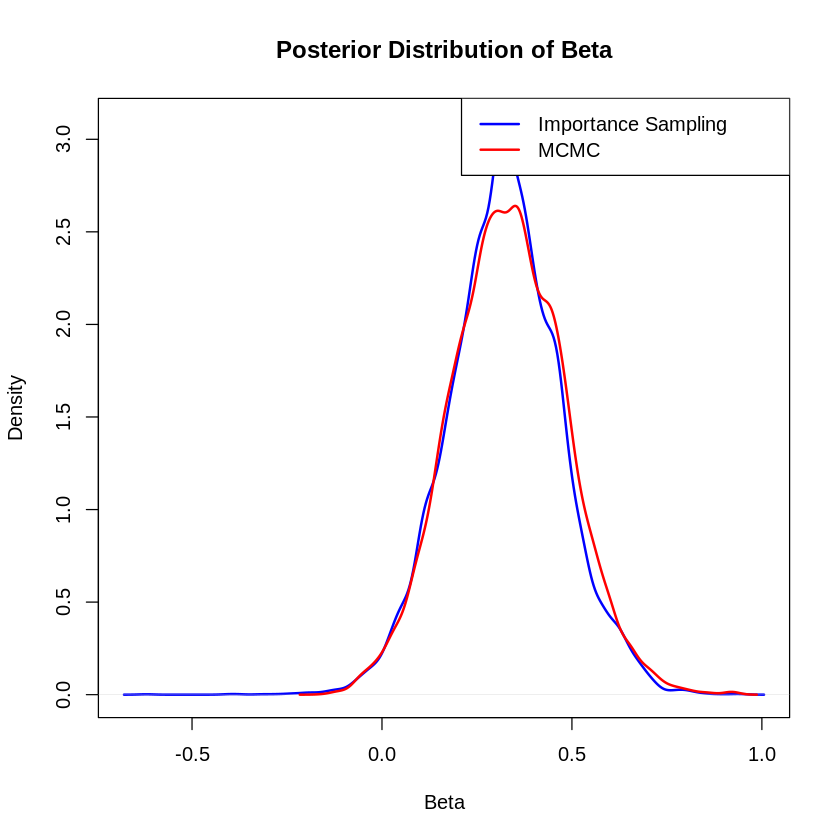

In [ ]:
plot(density(post_beta_is), col = "blue", lwd = 2, main = "Posterior Distribution of Beta",
     xlab = "Beta", ylim = c(0, max(density(post_beta_mcmc)$y, density(post_beta_is)$y)))
lines(density(post_beta_mcmc), col = "red", lwd = 2)
legend("topright", legend = c("Importance Sampling", "MCMC"), col = c("blue", "red"), lwd = 2)

##Exercise 4 & 5: Theory Interpretations

### Exercise 4
Because **μ_i = α + β * frequency**, and high-frequency words are encoded as 1, a faster recognition time requires a lower mean log-RT (**μ_i**). Therefore, the estimated posterior for the **β** parameter must be negative to support the hypothesis. If the mass of the distribution in your generated plot is concentrated below 0, the data supports the theory.

### Exercise 5
The **θ** parameter represents the probability with which the participant engages in the task. A high value estimate for **θ** implies that the participant is attentive, sincere, and properly performing the task as opposed to making random guesses.

##Part 2: Hamiltonian Monte Carlo (Base Setup)

In [ ]:
set.seed(42)
true_mu <- 800
true_var <- 100
y <- rnorm(500, mean = true_mu, sd = sqrt(true_var))

gradient <- function(mu, sigma, y, n, m, s, a, b){
  grad_mu <- (((n*mu)-sum(y))/(sigma^2))+((mu-m)/(s^2))
  grad_sigma <- (n/sigma)-(sum((y-mu)^2)/(sigma^3))+((sigma-a)/(b^2))
  return(c(grad_mu, grad_sigma))
}

V <- function(mu, sigma, y, n, m, s, a, b){
  nlpd <- -(sum(dnorm(y, mu, sigma, log=T)) + dnorm(mu, m, s, log=T) + dnorm(sigma, a, b, log=T))
  return(nlpd)
}

HMC <- function(y, n, m, s, a, b, step, L, initial_q, nsamp, nburn) {
  mu_chain <- rep(NA, nsamp)
  sigma_chain <- rep(NA, nsamp)
  reject <- 0

  mu_chain[1] <- initial_q[1]
  sigma_chain[1] <- initial_q[2]

  i <- 1
  while(i < nsamp) {
    q <- c(mu_chain[i], sigma_chain[i])
    p <- rnorm(length(q), 0, 1)

    current_q <- q
    current_p <- p
    current_V <- V(current_q[1], current_q[2], y, n, m, s, a, b)
    current_T <- sum(current_p^2)/2

    for(l in 1:L) {
      p <- p - ((step/2) * gradient(q[1], q[2], y, n, m, s, a, b))
      q <- q + step * p
      p <- p - ((step/2) * gradient(q[1], q[2], y, n, m, s, a, b))
    }

    proposed_q <- q
    proposed_p <- p

    if(proposed_q[2] <= 0) {
      accept.prob <- 0
    } else {
      proposed_V <- V(proposed_q[1], proposed_q[2], y, n, m, s, a, b)
      proposed_T <- sum(proposed_p^2)/2
      accept.prob <- min(1, exp(current_V + current_T - proposed_V - proposed_T))
    }

    if(!is.na(accept.prob) && runif(1, 0, 1) < accept.prob) {
      mu_chain[i+1] <- proposed_q[1]
      sigma_chain[i+1] <- proposed_q[2]
      i <- i + 1
    } else {
      reject <- reject + 1
      mu_chain[i+1] <- mu_chain[i]
      sigma_chain[i+1] <- sigma_chain[i]
      i <- i + 1
    }
  }
  posteriors <- data.frame(mu_chain, sigma_chain)[-(1:nburn),]
  posteriors$sample_id <- 1:nrow(posteriors)
  return(posteriors)
}

##Exercise 2.1: Base HMC Posterior

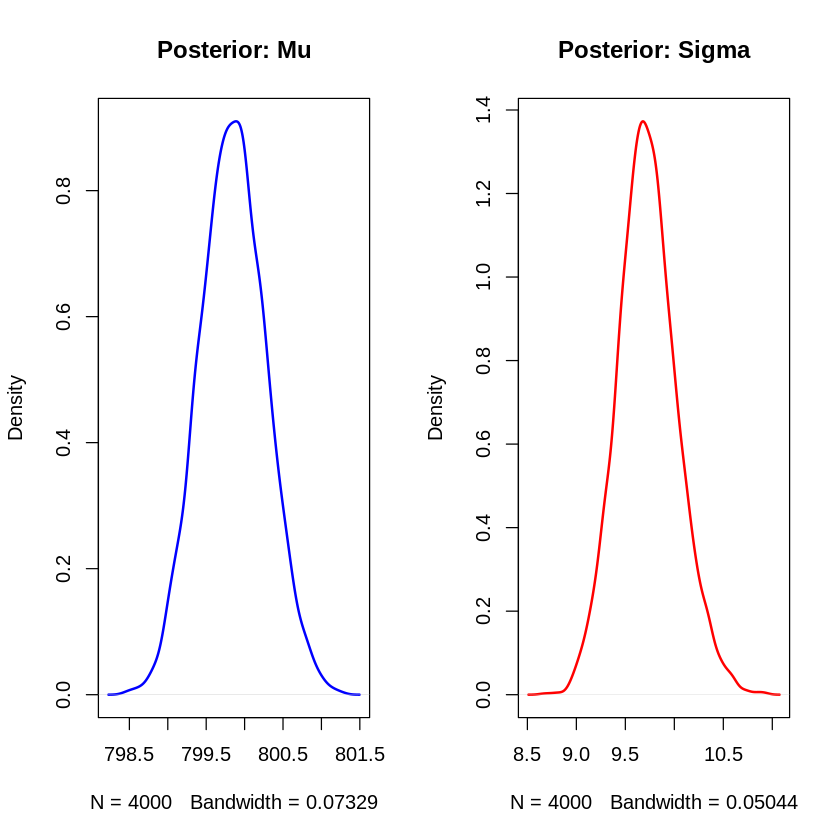

In [ ]:
df.posterior <- HMC(y=y, n=length(y), m=1000, s=20, a=10, b=2,
                    step=0.02, L=12, initial_q=c(1000,11), nsamp=6000, nburn=2000)

par(mfrow=c(1,2))
plot(density(df.posterior$mu_chain), main="Posterior: Mu", col="blue", lwd=2)
plot(density(df.posterior$sigma_chain), main="Posterior: Sigma", col="red", lwd=2)

##Exercise 2.2: Sensitivity to total number of samples

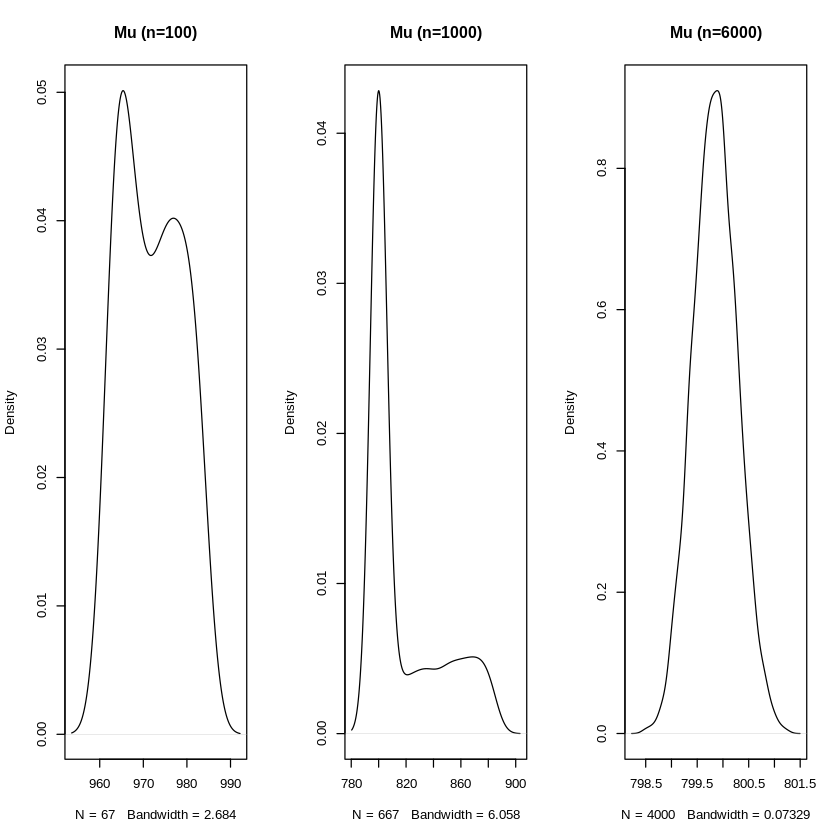

In [ ]:
df.100 <- HMC(y=y, n=length(y), m=1000, s=20, a=10, b=2, step=0.02, L=12, initial_q=c(1000,11), nsamp=100, nburn=33)
df.1000 <- HMC(y=y, n=length(y), m=1000, s=20, a=10, b=2, step=0.02, L=12, initial_q=c(1000,11), nsamp=1000, nburn=333)

par(mfrow=c(1,3))
plot(density(df.100$mu_chain), main="Mu (n=100)")
plot(density(df.1000$mu_chain), main="Mu (n=1000)")
plot(density(df.posterior$mu_chain), main="Mu (n=6000)")

##Exercise 2.3 & 2.4: Step-Size Parameters

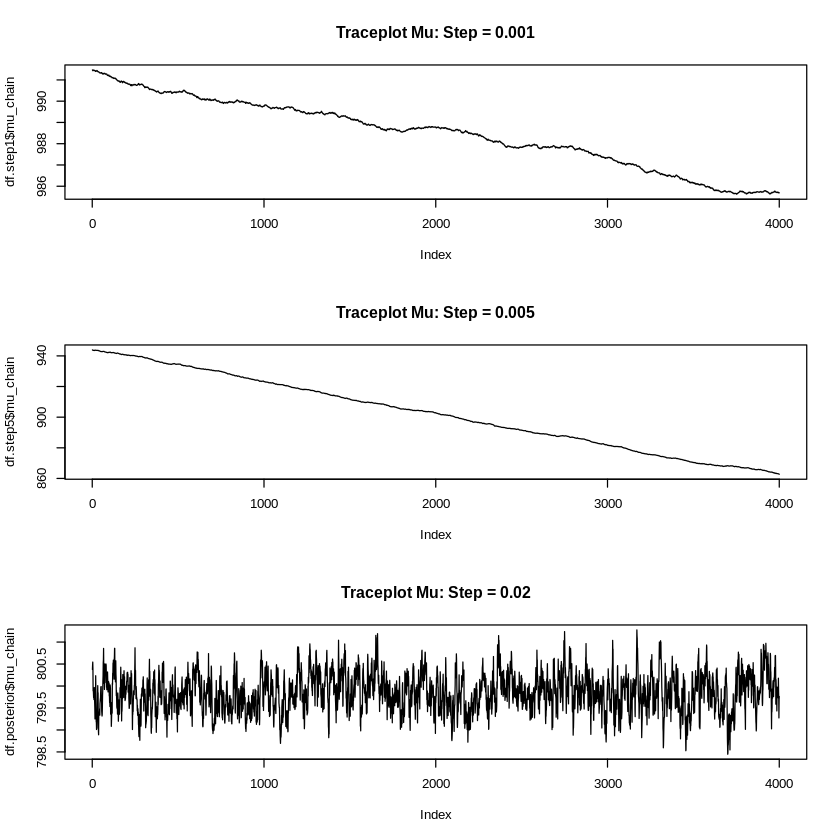

In [ ]:
df.step1 <- HMC(y=y, n=length(y), m=1000, s=20, a=10, b=2, step=0.001, L=12, initial_q=c(1000,11), nsamp=6000, nburn=2000)
df.step5 <- HMC(y=y, n=length(y), m=1000, s=20, a=10, b=2, step=0.005, L=12, initial_q=c(1000,11), nsamp=6000, nburn=2000)

par(mfrow=c(3,1))
plot(df.step1$mu_chain, type="l", main="Traceplot Mu: Step = 0.001")
plot(df.step5$mu_chain, type="l", main="Traceplot Mu: Step = 0.005")
plot(df.posterior$mu_chain, type="l", main="Traceplot Mu: Step = 0.02")

### Interpretation (Exercise 2.4)
Visual inspection of the chain with a step size of `0.001` shows extreme autocorrelation. Instead of a rapidly fluctuating "fuzzy caterpillar" traceplot (indicating good mixing), the plot looks like a slow, drifting wave. This proves the sampler is taking overly cautious, tiny steps and is failing to explore the target distribution efficiently.

##Exercise 2.5: Prior Sensitivity for Mu

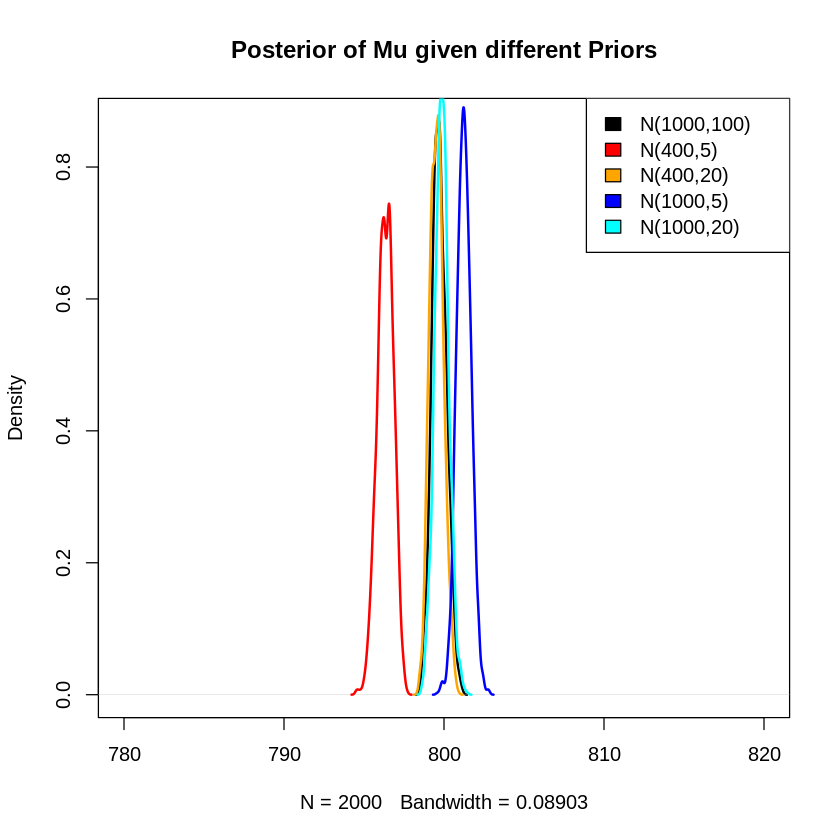

In [ ]:
prior_1 <- HMC(y=y, n=length(y), m=400, s=5, a=10, b=2, step=0.02, L=12, initial_q=c(800,11), nsamp=3000, nburn=1000)
prior_2 <- HMC(y=y, n=length(y), m=400, s=20, a=10, b=2, step=0.02, L=12, initial_q=c(800,11), nsamp=3000, nburn=1000)
prior_3 <- HMC(y=y, n=length(y), m=1000, s=5, a=10, b=2, step=0.02, L=12, initial_q=c(800,11), nsamp=3000, nburn=1000)
prior_4 <- HMC(y=y, n=length(y), m=1000, s=20, a=10, b=2, step=0.02, L=12, initial_q=c(800,11), nsamp=3000, nburn=1000)
prior_5 <- HMC(y=y, n=length(y), m=1000, s=100, a=10, b=2, step=0.02, L=12, initial_q=c(800,11), nsamp=3000, nburn=1000)

par(mfrow=c(1,1))
plot(density(prior_5$mu_chain), col="black", lwd=2, main="Posterior of Mu given different Priors", xlim=c(780, 820))
lines(density(prior_1$mu_chain), col="red", lwd=2)
lines(density(prior_2$mu_chain), col="orange", lwd=2)
lines(density(prior_3$mu_chain), col="blue", lwd=2)
lines(density(prior_4$mu_chain), col="cyan", lwd=2)
legend("topright", legend=c("N(1000,100)","N(400,5)", "N(400,20)", "N(1000,5)", "N(1000,20)"),
       fill=c("black", "red", "orange", "blue", "cyan"))

### Interpretation (Exercise 2.5)
When **s** (standard deviation) is large (e.g., **s=100**), the prior is "weak" or uninformative. The data overrides it easily, and the posterior centers neatly around the true mean (800). When **s** is very small (e.g., **s=5**), the prior is highly confident. If the assumed mean **m** is far off (like **m=400** or **1000**), the posterior is forcefully pulled away from the true data mean, proving that strong, incorrectly specified priors heavily bias Bayesian models.